In [ ]:
!git clone https://github.com/TheAtticusProject/cuad.git

Cloning into 'cuad'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 30 (delta 10), reused 9 (delta 9), pack-reused 13 (from 1)
Receiving objects: 100% (30/30), 17.78 MiB | 22.61 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [ ]:
!ls cuad

category_descriptions.csv  data.zip	readme.md  scrape.py  utils.py
contract_review.png	   evaluate.py	run.sh	   train.py


In [ ]:
!unzip -q cuad/data.zip -d cuad_data

In [ ]:
!find cuad_data -maxdepth 2 -type f | head -20

cuad_data/train_separate_questions.json
cuad_data/CUADv1.json
cuad_data/test.json


In [ ]:
import json

with open("cuad_data/CUADv1.json", "r") as f:
    data = json.load(f)

print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['version', 'data'])


In [ ]:
print("Number of contracts:", len(data["data"]))

print("\nFirst contract keys:")
print(data["data"][0].keys())

Number of contracts: 510

First contract keys:
dict_keys(['title', 'paragraphs'])


In [ ]:
first_contract = data["data"][0]

print("Number of paragraphs:", len(first_contract["paragraphs"]))

print("\nFirst paragraph keys:")
print(first_contract["paragraphs"][0].keys())

Number of paragraphs: 1

First paragraph keys:
dict_keys(['qas', 'context'])


In [ ]:
first_para = first_contract["paragraphs"][0]

print("Context preview:")
print(first_para["context"][:500])

print("\nQA keys:")
print(first_para["qas"][0].keys())

print("\nFirst Question:")
print(first_para["qas"][0]["question"])

print("\nFirst Answer:")
print(first_para["qas"][0]["answers"])

Context preview:
EXHIBIT 10.6

                              DISTRIBUTOR AGREEMENT

         THIS  DISTRIBUTOR  AGREEMENT (the  "Agreement")  is made by and between Electric City Corp.,  a Delaware  corporation  ("Company")  and Electric City of Illinois LLC ("Distributor") this 7th day of September, 1999.

                                    RECITALS

         A. The  Company's  Business.  The Company is  presently  engaged in the business  of selling an energy  efficiency  device,  which is  referred to as an 

QA keys:
dict_keys(['answers', 'id', 'question', 'is_impossible'])

First Question:
Highlight the parts (if any) of this contract related to "Document Name" that should be reviewed by a lawyer. Details: The name of the contract

First Answer:
[{'text': 'DISTRIBUTOR AGREEMENT', 'answer_start': 44}]


In [ ]:
samples = []

for contract in data["data"]:
    for paragraph in contract["paragraphs"]:
        for qa in paragraph["qas"]:

            question = qa["question"]
            answers = qa["answers"]

            # Answer unte matrame
            if len(answers) > 0:
                for answer in answers:
                    samples.append({
                        "text": answer["text"],
                        "question": question
                    })

print("Total extracted samples:", len(samples))

# First 5 samples
for i in range(5):
    print("\nSample", i + 1)
    print("TEXT:", samples[i]["text"])
    print("QUESTION:", samples[i]["question"])

Total extracted samples: 13823

Sample 1
TEXT: DISTRIBUTOR AGREEMENT
QUESTION: Highlight the parts (if any) of this contract related to "Document Name" that should be reviewed by a lawyer. Details: The name of the contract

Sample 2
TEXT: Distributor
QUESTION: Highlight the parts (if any) of this contract related to "Parties" that should be reviewed by a lawyer. Details: The two or more parties who signed the contract

Sample 3
TEXT: Electric City Corp.
QUESTION: Highlight the parts (if any) of this contract related to "Parties" that should be reviewed by a lawyer. Details: The two or more parties who signed the contract

Sample 4
TEXT: Electric City of Illinois L.L.C.
QUESTION: Highlight the parts (if any) of this contract related to "Parties" that should be reviewed by a lawyer. Details: The two or more parties who signed the contract

Sample 5
TEXT: Company
QUESTION: Highlight the parts (if any) of this contract related to "Parties" that should be reviewed by a lawyer. Details: The 

In [ ]:
import re

def extract_label(question):
    match = re.search(r'related to "([^"]+)"', question)

    if match:
        return match.group(1)
    else:
        return "Unknown"


# Add labels to samples
for sample in samples:
    sample["label"] = extract_label(sample["question"])


# First 10 samples check
for i in range(10):
    print("TEXT:", samples[i]["text"])
    print("LABEL:", samples[i]["label"])
    print("-" * 50)

TEXT: DISTRIBUTOR AGREEMENT
LABEL: Document Name
--------------------------------------------------
TEXT: Distributor
LABEL: Parties
--------------------------------------------------
TEXT: Electric City Corp.
LABEL: Parties
--------------------------------------------------
TEXT: Electric City of Illinois L.L.C.
LABEL: Parties
--------------------------------------------------
TEXT: Company
LABEL: Parties
--------------------------------------------------
TEXT: Electric City of Illinois LLC
LABEL: Parties
--------------------------------------------------
TEXT: 7th day of September, 1999.
LABEL: Agreement Date
--------------------------------------------------
TEXT: The term of this  Agreement  shall be ten (10)                            years (the "Term")  which shall  commence on the date                            upon which the Company  delivers to  Distributor  the                            last Sample, as defined  hereinafter.
LABEL: Effective Date
----------------------------

In [ ]:
import pandas as pd

df = pd.DataFrame(samples)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (13823, 3)


,text,question,label
0,DISTRIBUTOR AGREEMENT,Highlight the parts (if any) of this contract ...,Document Name
1,Distributor,Highlight the parts (if any) of this contract ...,Parties
2,Electric City Corp.,Highlight the parts (if any) of this contract ...,Parties
3,Electric City of Illinois L.L.C.,Highlight the parts (if any) of this contract ...,Parties
4,Company,Highlight the parts (if any) of this contract ...,Parties


In [ ]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nUnique labels:")
print(df["label"].nunique())

Dataset shape: (13823, 3)

Missing values:
text        0
question    0
label       0
dtype: int64

Duplicate rows:
720

Unique labels:
41


In [ ]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (13103, 3)


In [ ]:
print(df["label"].value_counts())

label
Parties                               2165
License Grant                          768
Cap On Liability                       670
Anti-Assignment                        648
Audit Rights                           642
Insurance                              560
Agreement Date                         467
Expiration Date                        463
Governing Law                          454
Post-Termination Services              450
Effective Date                         437
Minimum Commitment                     424
Revenue/Profit Sharing                 416
Exclusivity                            410
Rofr/Rofo/Rofn                         366
Ip Ownership Assignment                314
Non-Transferable License               294
Document Name                          274
Non-Compete                            259
Change Of Control                      252
Termination For Convenience            243
Renewal Term                           208
Warranty Duration                      176
Volum

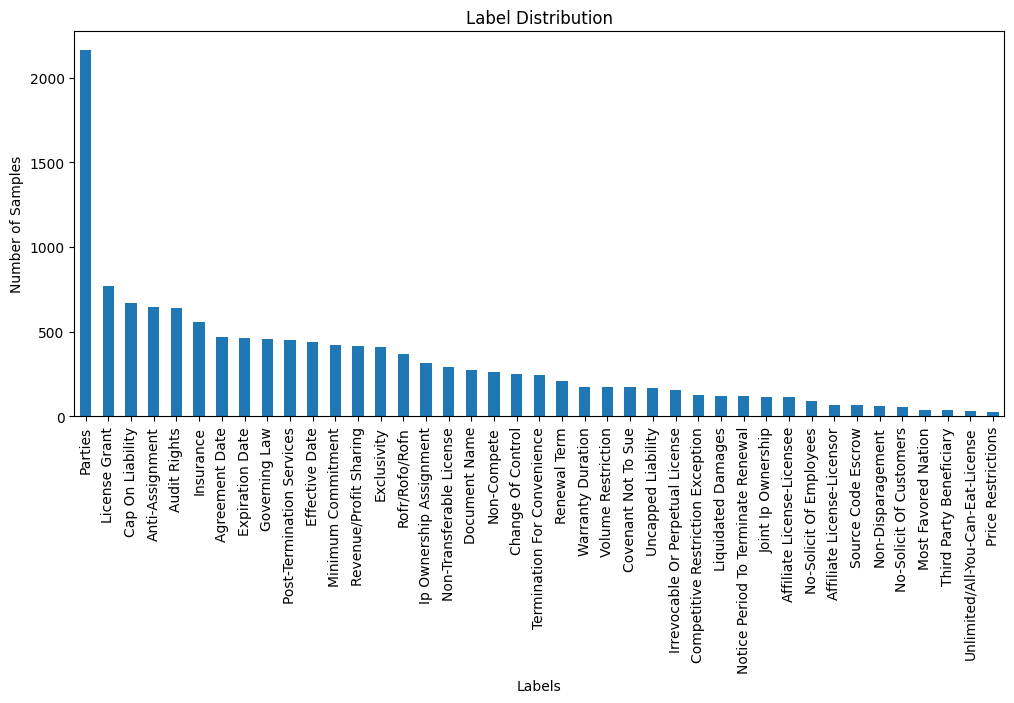

In [ ]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar", figsize=(12,5))
plt.xlabel("Labels")
plt.ylabel("Number of Samples")
plt.title("Label Distribution")
plt.show()

In [ ]:
print(df.head())
print(df["text"].head())
print(df["question"].head())

                               text  \
0             DISTRIBUTOR AGREEMENT   
1                       Distributor   
2               Electric City Corp.   
3  Electric City of Illinois L.L.C.   
4                           Company   

                                            question          label  
0  Highlight the parts (if any) of this contract ...  Document Name  
1  Highlight the parts (if any) of this contract ...        Parties  
2  Highlight the parts (if any) of this contract ...        Parties  
3  Highlight the parts (if any) of this contract ...        Parties  
4  Highlight the parts (if any) of this contract ...        Parties  
0               DISTRIBUTOR AGREEMENT
1                         Distributor
2                 Electric City Corp.
3    Electric City of Illinois L.L.C.
4                             Company
Name: text, dtype: object
0    Highlight the parts (if any) of this contract ...
1    Highlight the parts (if any) of this contract ...
2    Highlight the 

In [ ]:
df["input_text"] = df["text"].astype(str) + " " + df["question"].astype(str)

print(df[["input_text", "label"]].head())

                                          input_text          label
0  DISTRIBUTOR AGREEMENT Highlight the parts (if ...  Document Name
1  Distributor Highlight the parts (if any) of th...        Parties
2  Electric City Corp. Highlight the parts (if an...        Parties
3  Electric City of Illinois L.L.C. Highlight the...        Parties
4  Company Highlight the parts (if any) of this c...        Parties


In [ ]:
X = df["input_text"]
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (13103,)
y shape: (13103,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (10482,)
X_test: (2621,)
y_train: (10482,)
y_test: (2621,)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("X_train TF-IDF shape:", X_train_tfidf.shape)
print("X_test TF-IDF shape:", X_test_tfidf.shape)

X_train TF-IDF shape: (10482, 10000)
X_test TF-IDF shape: (2621, 10000)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [ ]:
y_pred = model.predict(X_test_tfidf)

print("Predictions completed!")
print("First 10 predictions:", y_pred[:10])

Predictions completed!
First 10 predictions: ['License Grant' 'Covenant Not To Sue' 'Effective Date' 'Document Name'
 'Exclusivity' 'Parties' 'License Grant' 'Post-Termination Services'
 'Parties' 'Cap On Liability']


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100)

Accuracy: 0.9992369324685234
Accuracy percentage: 99.92369324685234


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                                    precision    recall  f1-score   support

        Affiliate License-Licensee       1.00      1.00      1.00        23
        Affiliate License-Licensor       1.00      0.93      0.96        14
                    Agreement Date       1.00      1.00      1.00        93
                   Anti-Assignment       1.00      1.00      1.00       130
                      Audit Rights       1.00      1.00      1.00       128
                  Cap On Liability       1.00      1.00      1.00       134
                 Change Of Control       1.00      1.00      1.00        50
 Competitive Restriction Exception       1.00      1.00      1.00        25
               Covenant Not To Sue       1.00      1.00      1.00        34
                     Document Name       1.00      1.00      1.00        55
                    Effective Date       1.00      1.00      1.00        87
                       Exclusivity       1.00      1.00      1.00        82
           

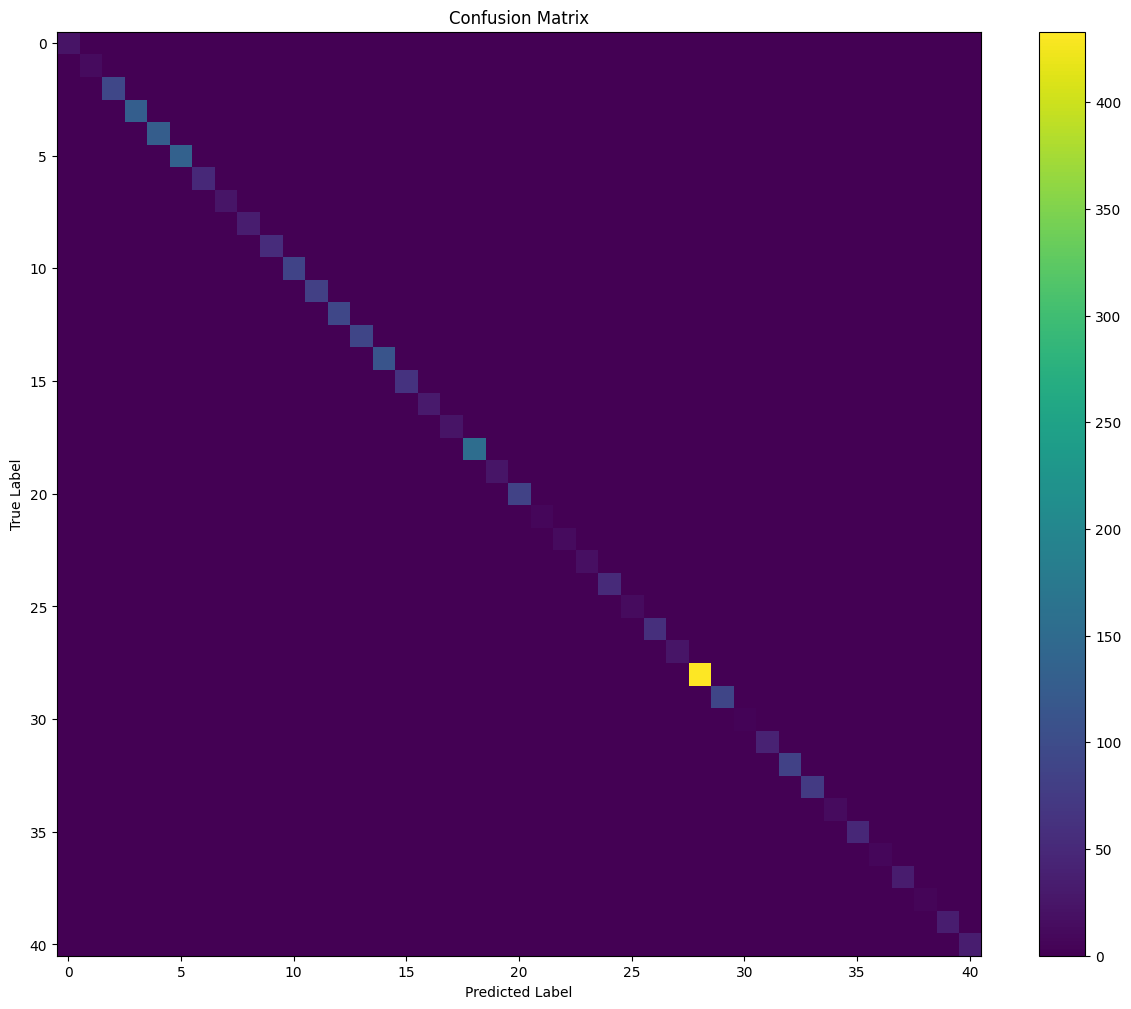

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(15, 12))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.show()

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_tfidf, y_train)

print("SVM model training completed!")

SVM model training completed!


In [ ]:
y_pred_svm = svm_model.predict(X_test_tfidf)

print("First 10 predictions:", y_pred_svm[:10])

First 10 predictions: ['License Grant' 'Covenant Not To Sue' 'Effective Date' 'Document Name'
 'Exclusivity' 'Parties' 'License Grant' 'Post-Termination Services'
 'Parties' 'Cap On Liability']


In [ ]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)
print("SVM Accuracy Percentage:", svm_accuracy * 100)

SVM Accuracy: 0.9996184662342618
SVM Accuracy Percentage: 99.96184662342617


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

                                    precision    recall  f1-score   support

        Affiliate License-Licensee       1.00      1.00      1.00        23
        Affiliate License-Licensor       1.00      1.00      1.00        14
                    Agreement Date       1.00      1.00      1.00        93
                   Anti-Assignment       1.00      1.00      1.00       130
                      Audit Rights       1.00      1.00      1.00       128
                  Cap On Liability       1.00      1.00      1.00       134
                 Change Of Control       1.00      1.00      1.00        50
 Competitive Restriction Exception       1.00      1.00      1.00        25
               Covenant Not To Sue       1.00      1.00      1.00        34
                     Document Name       1.00      1.00      1.00        55
                    Effective Date       1.00      1.00      1.00        87
                       Exclusivity       1.00      1.00      1.00        82
           

In [ ]:
print("Logistic Regression Accuracy:", accuracy * 100)
print("Linear SVM Accuracy:", svm_accuracy * 100)

Logistic Regression Accuracy: 99.92369324685234
Linear SVM Accuracy: 99.96184662342617


In [ ]:
best_model = svm_model

print("Selected Best Model: Linear SVM")
print("Accuracy:", svm_accuracy * 100)

Selected Best Model: Linear SVM
Accuracy: 99.96184662342617


In [ ]:
new_text = "The distributor shall be responsible for all payments and obligations."

new_input = tfidf.transform([new_text])

prediction = best_model.predict(new_input)

print("Predicted Contract Category:", prediction[0])

Predicted Contract Category: Anti-Assignment


In [ ]:
from sklearn.metrics import classification_report

print("Linear SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

Linear SVM Classification Report:
                                    precision    recall  f1-score   support

        Affiliate License-Licensee       1.00      1.00      1.00        23
        Affiliate License-Licensor       1.00      1.00      1.00        14
                    Agreement Date       1.00      1.00      1.00        93
                   Anti-Assignment       1.00      1.00      1.00       130
                      Audit Rights       1.00      1.00      1.00       128
                  Cap On Liability       1.00      1.00      1.00       134
                 Change Of Control       1.00      1.00      1.00        50
 Competitive Restriction Exception       1.00      1.00      1.00        25
               Covenant Not To Sue       1.00      1.00      1.00        34
                     Document Name       1.00      1.00      1.00        55
                    Effective Date       1.00      1.00      1.00        87
                       Exclusivity       1.00      1.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_svm, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred_svm, average="weighted"))

Accuracy : 0.9996184662342618
Precision: 0.9996226589130061
Recall   : 0.9996184662342618
F1 Score : 0.9996154613250922


In [ ]:
def calculate_risk_score(predicted_label):

    high_risk = [
        "Uncapped Liability",
        "Anti-Assignment",
        "Non-Compete",
        "Irrevocable Or Perpetual License",
        "Ip Ownership Assignment",
        "Liquidated Damages"
    ]

    medium_risk = [
        "Audit Rights",
        "Change Of Control",
        "Exclusivity",
        "Minimum Commitment",
        "Termination For Convenience",
        "Volume Restriction",
        "Price Restrictions"
    ]

    low_risk = [
        "Document Name",
        "Agreement Date",
        "Effective Date",
        "Expiration Date",
        "Parties",
        "Governing Law"
    ]

    if predicted_label in high_risk:
        return 80, "High Risk"

    elif predicted_label in medium_risk:
        return 50, "Medium Risk"

    elif predicted_label in low_risk:
        return 20, "Low Risk"

    else:
        return 40, "Medium Risk"

In [ ]:
predicted_label = prediction[0]

risk_score, risk_level = calculate_risk_score(predicted_label)

print("Predicted Category:", predicted_label)
print("Risk Score:", risk_score, "/ 100")
print("Risk Level:", risk_level)

Predicted Category: Anti-Assignment
Risk Score: 80 / 100
Risk Level: High Risk


In [ ]:
contract_clauses = [
    "The distributor shall be responsible for all payments and obligations.",
    "The agreement shall remain effective for five years.",
    "The license granted under this agreement is irrevocable and perpetual.",
    "The company shall have the right to audit the records.",
    "Neither party may assign this agreement without prior written consent."
]

results = []

for clause in contract_clauses:
    clause_tfidf = tfidf.transform([clause])
    predicted_label = best_model.predict(clause_tfidf)[0]

    score, level = calculate_risk_score(predicted_label)

    results.append({
        "Clause": clause,
        "Category": predicted_label,
        "Risk Score": score,
        "Risk Level": level
    })

for result in results:
    print("\nClause:", result["Clause"])
    print("Category:", result["Category"])
    print("Risk Score:", result["Risk Score"])
    print("Risk Level:", result["Risk Level"])


Clause: The distributor shall be responsible for all payments and obligations.
Category: Anti-Assignment
Risk Score: 80
Risk Level: High Risk

Clause: The agreement shall remain effective for five years.
Category: Effective Date
Risk Score: 20
Risk Level: Low Risk

Clause: The license granted under this agreement is irrevocable and perpetual.
Category: Irrevocable Or Perpetual License
Risk Score: 80
Risk Level: High Risk

Clause: The company shall have the right to audit the records.
Category: Audit Rights
Risk Score: 50
Risk Level: Medium Risk

Clause: Neither party may assign this agreement without prior written consent.
Category: Anti-Assignment
Risk Score: 80
Risk Level: High Risk


In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)

overall_score = results_df["Risk Score"].mean()

if overall_score >= 70:
    overall_level = "High Risk"
elif overall_score >= 40:
    overall_level = "Medium Risk"
else:
    overall_level = "Low Risk"

print("Overall Contract Risk Score:", round(overall_score, 2), "/ 100")
print("Overall Contract Risk Level:", overall_level)

print("\nRisk Summary:")
print(results_df["Risk Level"].value_counts())

Overall Contract Risk Score: 62.0 / 100
Overall Contract Risk Level: Medium Risk

Risk Summary:
Risk Level
High Risk      3
Low Risk       1
Medium Risk    1
Name: count, dtype: int64


In [ ]:
import os

print(os.listdir())

['.config', 'cuad_data', 'cuad', 'sample_data']


In [ ]:
df.to_csv("/content/cleaned_contract_dataset.csv", index=False)
print("✅ Dataset saved")

✅ Dataset saved


In [ ]:
import joblib

joblib.dump(best_model, "/content/contract_svm_model.pkl")
joblib.dump(tfidf, "/content/tfidf_vectorizer.pkl")

print("✅ Model saved")
print("✅ TF-IDF saved")

✅ Model saved
✅ TF-IDF saved


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'cleaned_contract_dataset.csv', 'tfidf_vectorizer.pkl', 'contract_svm_model.pkl', 'cuad_data', 'cuad', 'sample_data']


In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)

overall_score = results_df["Risk Score"].mean()

if overall_score >= 70:
    overall_level = "High Risk"
elif overall_score >= 40:
    overall_level = "Medium Risk"
else:
    overall_level = "Low Risk"

print("Overall Contract Risk Score:", round(overall_score, 2), "/ 100")
print("Overall Contract Risk Level:", overall_level)

print("\nRisk Summary:")
print(results_df["Risk Level"].value_counts())

Overall Contract Risk Score: 62.0 / 100
Overall Contract Risk Level: Medium Risk

Risk Summary:
Risk Level
High Risk      3
Low Risk       1
Medium Risk    1
Name: count, dtype: int64


In [ ]:
top_risks = results_df.sort_values(
    by="Risk Score",
    ascending=False
)

print("TOP RISKY CLAUSES")
print("=" * 80)

for i, row in top_risks.head(3).iterrows():
    print("\nCategory:", row["Category"])
    print("Risk Score:", row["Risk Score"], "/ 100")
    print("Risk Level:", row["Risk Level"])
    print("Clause:", row["Clause"])
    print("-" * 80)

TOP RISKY CLAUSES

Category: Anti-Assignment
Risk Score: 80 / 100
Risk Level: High Risk
Clause: The distributor shall be responsible for all payments and obligations.
--------------------------------------------------------------------------------

Category: Irrevocable Or Perpetual License
Risk Score: 80 / 100
Risk Level: High Risk
Clause: The license granted under this agreement is irrevocable and perpetual.
--------------------------------------------------------------------------------

Category: Anti-Assignment
Risk Score: 80 / 100
Risk Level: High Risk
Clause: Neither party may assign this agreement without prior written consent.
--------------------------------------------------------------------------------


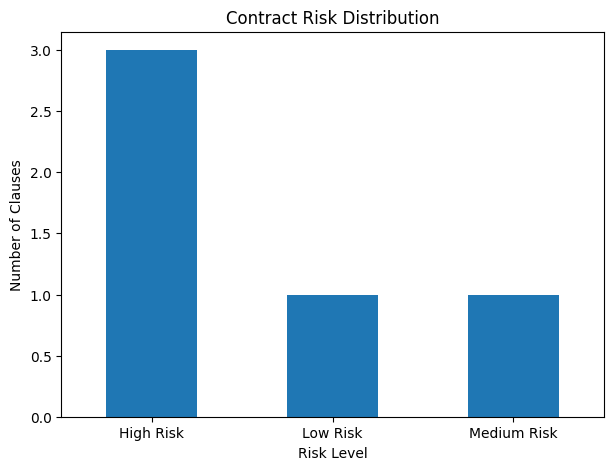

In [ ]:
import matplotlib.pyplot as plt

risk_counts = results_df["Risk Level"].value_counts()

plt.figure(figsize=(7, 5))
risk_counts.plot(kind="bar")

plt.title("Contract Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Clauses")
plt.xticks(rotation=0)

plt.show()

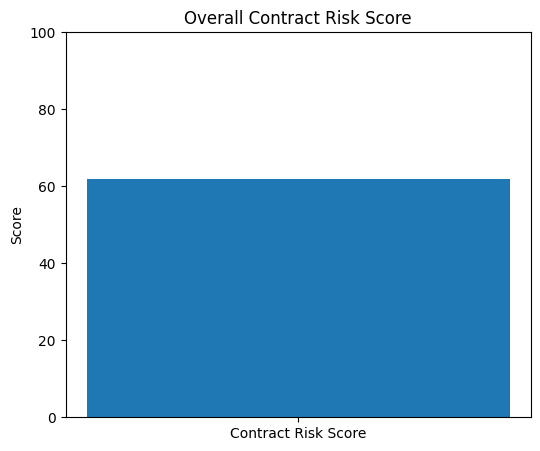

In [ ]:
plt.figure(figsize=(6, 5))

plt.bar(["Contract Risk Score"], [overall_score])
plt.ylim(0, 100)

plt.title("Overall Contract Risk Score")
plt.ylabel("Score")

plt.show()

In [ ]:
contract_text = """
This Agreement is entered into between ABC Company and XYZ Distributor.
The agreement shall remain effective for five years.
The distributor shall not assign this agreement without prior written consent.
The license granted under this agreement is irrevocable and perpetual.
The company shall have the right to audit the distributor's records.
"""

# Split contract into clauses
contract_clauses = [
    clause.strip()
    for clause in contract_text.split(".")
    if clause.strip()
]

results = []

for clause in contract_clauses:
    clause_tfidf = tfidf.transform([clause])
    predicted_label = best_model.predict(clause_tfidf)[0]

    score, level = calculate_risk_score(predicted_label)

    results.append({
        "Clause": clause,
        "Category": predicted_label,
        "Risk Score": score,
        "Risk Level": level
    })

results_df = pd.DataFrame(results)

overall_score = results_df["Risk Score"].mean()

if overall_score >= 70:
    overall_level = "High Risk"
elif overall_score >= 40:
    overall_level = "Medium Risk"
else:
    overall_level = "Low Risk"

print("===== CONTRACT INTELLIGENCE REPORT =====")
print("Overall Risk Score:", round(overall_score, 2), "/ 100")
print("Overall Risk Level:", overall_level)

print("\nClause Analysis:")
print(results_df[["Category", "Risk Score", "Risk Level"]])

print("\nRisk Summary:")
print(results_df["Risk Level"].value_counts())

===== CONTRACT INTELLIGENCE REPORT =====
Overall Risk Score: 50.0 / 100
Overall Risk Level: Medium Risk

Clause Analysis:
                           Category  Risk Score   Risk Level
0                    Agreement Date          20     Low Risk
1                    Effective Date          20     Low Risk
2                   Anti-Assignment          80    High Risk
3  Irrevocable Or Perpetual License          80    High Risk
4                      Audit Rights          50  Medium Risk

Risk Summary:
Risk Level
Low Risk       2
High Risk      2
Medium Risk    1
Name: count, dtype: int64


In [ ]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Check exact overlap between training and testing data
overlap = set(X_train).intersection(set(X_test))

print("Exact overlapping samples:", len(overlap))

Training samples: 10482
Testing samples: 2621
Exact overlapping samples: 0


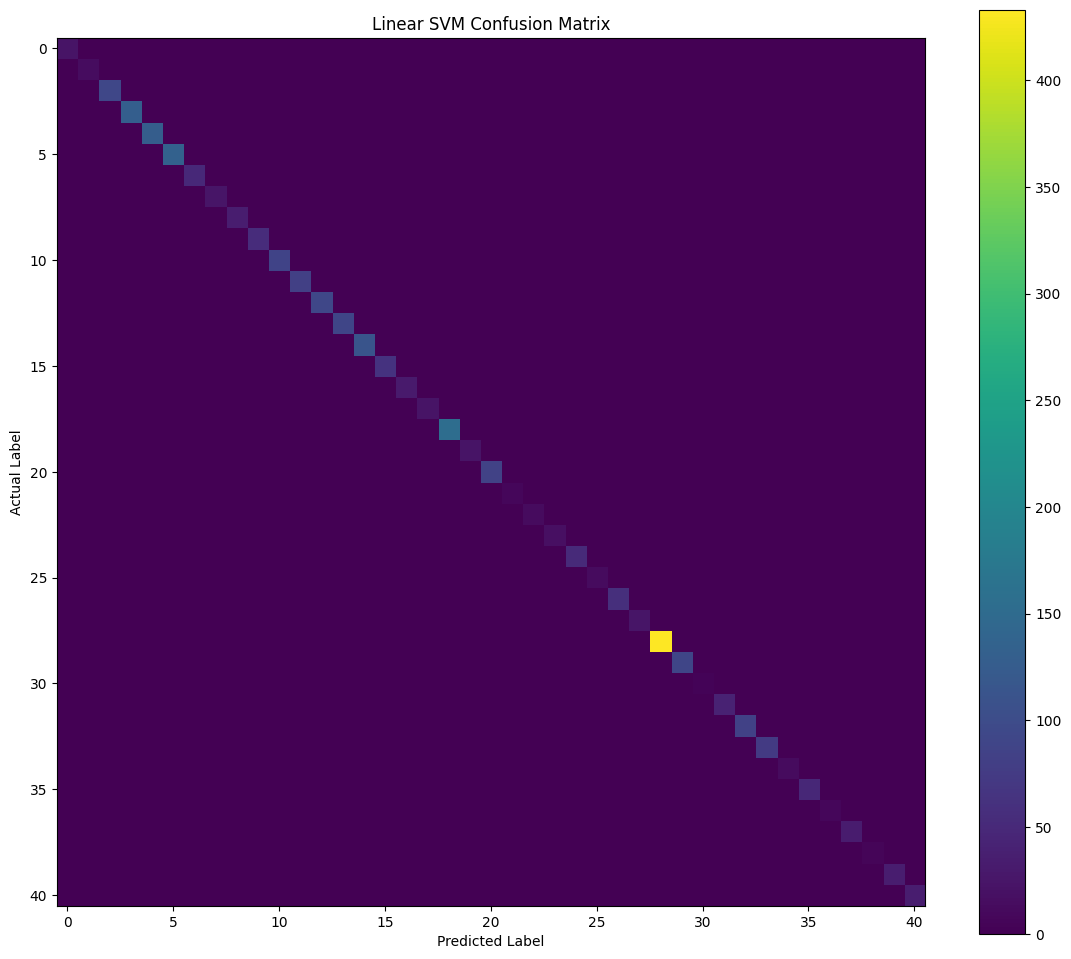

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(14, 12))
plt.imshow(cm)
plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.colorbar()
plt.show()

In [ ]:
import joblib

joblib.dump(best_model, "/content/contract_svm_model.pkl")
joblib.dump(tfidf, "/content/tfidf_vectorizer.pkl")

print("✅ Final model saved successfully!")
print("✅ TF-IDF vectorizer saved successfully!")

✅ Final model saved successfully!
✅ TF-IDF vectorizer saved successfully!


In [ ]:
loaded_model = joblib.load("/content/contract_svm_model.pkl")
loaded_tfidf = joblib.load("/content/tfidf_vectorizer.pkl")

test_text = "The license granted under this agreement is irrevocable and perpetual."

test_vector = loaded_tfidf.transform([test_text])
test_prediction = loaded_model.predict(test_vector)

print("Test Prediction:", test_prediction[0])

Test Prediction: Irrevocable Or Perpetual License


In [ ]:
print(df.columns.tolist())

['text', 'question', 'label', 'input_text']


In [ ]:
import json

sample_output = {
    "document_id": "DOC-001",
    "contract_filename": "sample_contract.txt",
    "extracted_text": contract_text,
    "parties": [
        "ABC Company",
        "XYZ Distributor"
    ],
    "dates": {
        "effective_date": None,
        "expiration_date": None
    },
    "jurisdiction": None,
    "monetary_values": [],
    "entity_structure": {
        "party_1": {
            "name": "ABC Company",
            "role": "Company"
        },
        "party_2": {
            "name": "XYZ Distributor",
            "role": "Distributor"
        }
    },
    "clause_analysis": results,
    "overall_risk_score": round(overall_score, 2),
    "overall_risk_level": overall_level
}

with open("/content/sample_processed_output.json", "w") as f:
    json.dump(sample_output, f, indent=4)

print("✅ Sample processed output saved!")

✅ Sample processed output saved!


In [ ]:
import os

print(os.path.exists("/content/sample_processed_output.json"))
print(os.listdir("/content"))

True
['.config', 'cleaned_contract_dataset.csv', 'tfidf_vectorizer.pkl', 'contract_svm_model.pkl', 'sample_processed_output.json', 'cuad_data', 'cuad', 'sample_data']


In [ ]:
with open("/content/sample_processed_output.json", "r") as f:
    print(f.read())

{
    "document_id": "DOC-001",
    "contract_filename": "sample_contract.txt",
    "extracted_text": "\nThis Agreement is entered into between ABC Company and XYZ Distributor.\nThe agreement shall remain effective for five years.\nThe distributor shall not assign this agreement without prior written consent.\nThe license granted under this agreement is irrevocable and perpetual.\nThe company shall have the right to audit the distributor's records.\n",
    "parties": [
        "ABC Company",
        "XYZ Distributor"
    ],
    "dates": {
        "effective_date": null,
        "expiration_date": null
    },
    "jurisdiction": null,
    "monetary_values": [],
    "entity_structure": {
        "party_1": {
            "name": "ABC Company",
            "role": "Company"
        },
        "party_2": {
            "name": "XYZ Distributor",
            "role": "Distributor"
        }
    },
    "clause_analysis": [
        {
            "Clause": "This Agreement is entered into between 

In [ ]:
from google.colab import files

files.download("/content/cleaned_contract_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("/content/contract_svm_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("/content/tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("/content/sample_processed_output.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>